In [8]:
# !pip install cupy-cuda12x
# !pip install cupy-cuda12x scipy statsmodels --upgrade


In [9]:
import cupy as cp
import numpy as np
import time 
import matplotlib.pyplot as plt

### Задание 1  
На вход функции подаётся массив размерностью $N$. Необходимо реализовать вычисление выражения $y = \sqrt{x}+sin(x)⋅exp(−x)$ (используйте встроенные векторные функции, обычный for не даст вам ускорения). Для экспериментов ограничим значение, которое может принимать $N$ в задачах следующим интервалом [1, 10000000].

In [10]:
def pretty_load(i, I, text="", bar_len = 50):
    l = round(i / I * bar_len)
    if text == "":
        text = round(i / I * 100)
    print(f"\r[{'*' * l}{' ' * (bar_len-l)}] {text}", end = "")

def plot_results(N_values, results, labels, 
                 title='График зависимости времени от N',
                 xlabel='Размер массива (N)', 
                 ylabel='Время выполнения (с)',
                 log_scale=False, 
                 marker='o', 
                 linestyle='-', 
                 figsize=(10, 6)):
    """
    Строит график зависимости времени выполнения от размера входных данных.

    Параметры:
        N_values (list): список значений N (ось X).
        results (list of lists): список, где каждый элемент содержит времена для одного N
                                  для разных алгоритмов. Например, [[t1_np, t1_cp], [t2_np, t2_cp], ...].
        labels (list): подписи для каждой линии (например, ['np', 'cp']).
        title (str): заголовок графика.
        xlabel (str): подпись оси X.
        ylabel (str): подпись оси Y.
        log_scale (bool): если True, оси будут в логарифмическом масштабе.
        marker (str): маркер точек.
        linestyle (str): стиль линии.
        figsize (tuple): размер фигуры (ширина, высота) в дюймах.
    """
    plt.figure(figsize=figsize)

    # Проверяем, что количество алгоритмов совпадает с длиной labels
    num_algorithms = len(results[0])
    if num_algorithms != len(labels):
        raise ValueError("Количество столбцов в results должно совпадать с количеством labels")

    # Для каждого алгоритма строим свою линию
    for j in range(num_algorithms):
        y_vals = [row[j] for row in results]
        plt.plot(N_values, y_vals, label=labels[j], marker=marker, linestyle=linestyle)

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    
    if log_scale:
        plt.xscale('log')
        plt.yscale('log')
    
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

[**************************************************] 100
N count     	np          	cp          
215000      	0.858896732 	0.019167344 
464000      	1.873986403 	0.024322669 
1000000     	3.501831611 	0.002908071 
2150000     	6.619288445 	0.002079964 
4640000     	14.479667425	0.004254897 
10000000    	38.792979956	0.008605878 


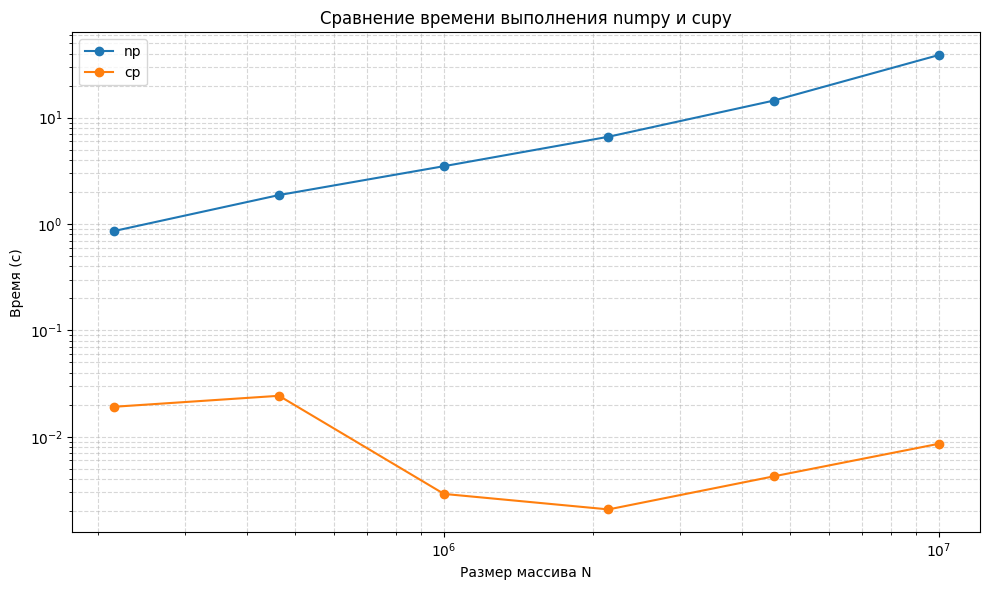

In [11]:
def compete1(N_mas, lib_mas, func_mas, counts=3):
    mmas = []
    for i, N in enumerate(N_mas):
        mmas.append([])
        for j, lib in enumerate(lib_mas):
            sum_time = 0
            for k in range(counts):
                pretty_load(i*len(lib_mas) + j, len(N_mas) * len(lib_mas))
                arr1 = lib.arange(N)
                vec_func = lib.vectorize(func_mas[j])
                start = time.time()
                result = vec_func(arr1) 
                sum_time += time.time() - start
            mmas[-1].append(sum_time/counts)
    pretty_load(len(N_mas) * len(lib_mas), len(N_mas) * len(lib_mas))
    return mmas

def func1_np(x):
    return np.sqrt(x) + np.sin(x)*np.exp(-x)

def func1_cp(x):
    return cp.sqrt(x) + cp.sin(x)*cp.exp(-x)

N_mas = [215000, 464000, 1000000, 2150000, 4640000, 10000000]
res = compete1(N_mas, [np, cp], [func1_np, func1_cp])

print(f"""\n{"N count":<12}\t{"np":<12}\t{"cp":<12}""")
for i, row in enumerate(res):
    print(f"{N_mas[i]:<12}\t{row[0]:<12.9f}\t{row[1]:<12.9f}")

plot_results(N_mas, res, labels=['np', 'cp'],
             title='Сравнение времени выполнения numpy и cupy',
             xlabel='Размер массива N', ylabel='Время (с)',
             log_scale=True)

### Задание 2.

Расчет статистик.

На вход функции подаётся квадртаная матрицы $A$ размерностью $N \times N$. Необходимо реализовать функцию рассчета статистик (среднее значение, медиана, мода, дисперсия, среднеквадартаичное отклонение, первый и третий квартиль) для каждой колонки матрицы. Для экспериментов ограничим значение, которое может принимать $N$ в задачах следующим интервалом [1, 100000].

[**************************************************] 100
N count     	np          	cp          
215         	0.008335431 	0.057175080 
464         	0.038860877 	0.006925344 
1000        	0.090407530 	0.003219604 
2150        	0.421567043 	0.003881613 
4640        	1.564588547 	0.440599998 
10000       	9.320424875 	8.537172953 
11000       	14.685082674	22.987601678
12000       	16.075476408	19.676148415
13000       	25.403581937	23.495517651


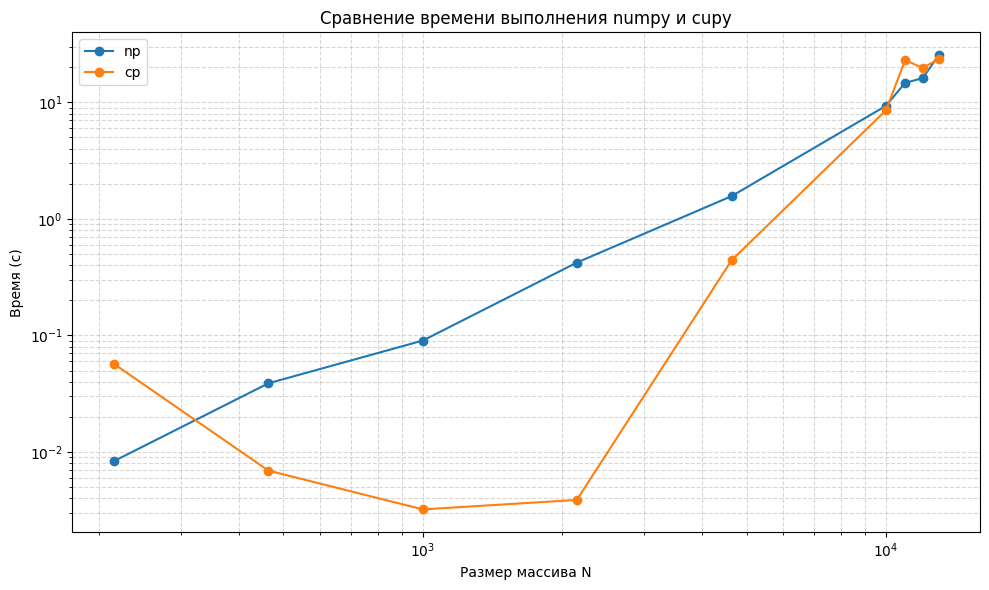

In [12]:
def compete2(N_mas, lib_mas, counts=3):
    mmas = []
    for i, N in enumerate(N_mas):
        mmas.append([])
        for j, lib in enumerate(lib_mas):
            sum_time = 0
            for k in range(counts):
                pretty_load(i*len(lib_mas) + j, len(N_mas) * len(lib_mas))
                arr1 = lib.random.rand(N, N)
                start = time.time()
                mean        = lib.mean(arr1, axis=1)
                median      = lib.median(arr1, axis=1)
                # mode        = mode_axis(arr1, axis=1)
                var         = lib.var(arr1, axis=1)
                std         = lib.std(arr1, axis=1)
                percentile_25         = lib.percentile(arr1, 25, axis=1)
                percentile_75         = lib.percentile(arr1, 75, axis=1)
                sum_time += time.time() - start

            mmas[-1].append(sum_time/counts)
    pretty_load(len(N_mas) * len(lib_mas), len(N_mas) * len(lib_mas))
    return mmas

N_mas = [215, 464, 1000, 2150, 4640, 10000, 11000, 12000, 13000]
res = compete2(N_mas, [np, cp])

print(f"""\n{"N count":<12}\t{"np":<12}\t{"cp":<12}""")
for i, row in enumerate(res):
    print(f"{N_mas[i]:<12}\t{row[0]:<12.9f}\t{row[1]:<12.9f}")


plot_results(N_mas, res, labels=['np', 'cp'],
             title='Сравнение времени выполнения numpy и cupy',
             xlabel='Размер массива N', ylabel='Время (с)',
             log_scale=True)

### Задание 3.

Матричное умножение.

На вход функции подаётся две квадртаная матрицы $A$ и $B$ размерностью $N \times N$. Необходимо реализовать вычисление их произведения $C = A \cdot B$. Для экспериментов ограничим значение, которое может принимать $N$ в задачах следующим интервалом [1, 4096].

[**************************************************] 100
N count     	np          	cp          
215         	0.005054156 	0.003091653 
464         	0.007483721 	0.002031167 
1000        	0.049590906 	0.001811345 
2150        	0.254193068 	0.000864029 
4640        	2.223764102 	0.000870466 
10000       	40.538242896	0.035873652 


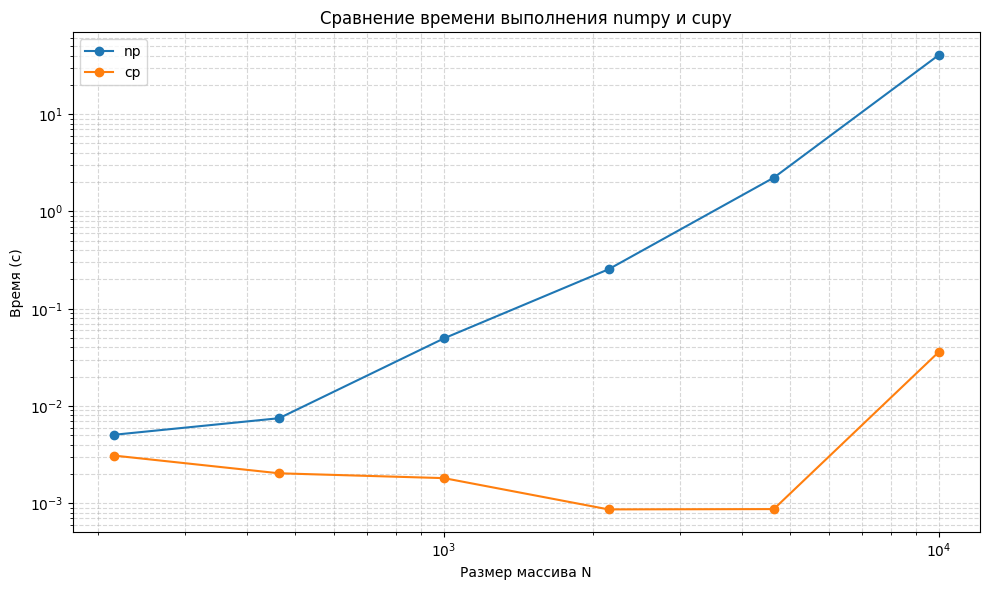

In [13]:
def compete3(N_mas, lib_mas, counts=3):
    mmas = []
    for i, N in enumerate(N_mas):
        mmas.append([])
        for j, lib in enumerate(lib_mas):
            sum_time = 0
            for k in range(counts):
                pretty_load(i*len(lib_mas) + j, len(N_mas) * len(lib_mas))
                arr1 = lib.random.rand(N, N)
                arr2 = lib.random.rand(N, N)
                start = time.time()
                res = lib.matmul(arr1, arr2)
                sum_time += time.time() - start
            mmas[-1].append(sum_time/counts)
    pretty_load(len(N_mas) * len(lib_mas), len(N_mas) * len(lib_mas))
    return mmas

N_mas = [215, 464, 1000, 2150, 4640, 10000]
# N_mas = [2150, 4640, 10000, 21500, 46400, 100000]
res = compete3(N_mas, [np, cp])

print(f"""\n{"N count":<12}\t{"np":<12}\t{"cp":<12}""")
for i, row in enumerate(res):
    print(f"{N_mas[i]:<12}\t{row[0]:<12.9f}\t{row[1]:<12.9f}")


plot_results(N_mas, res, labels=['np', 'cp'],
             title='Сравнение времени выполнения numpy и cupy',
             xlabel='Размер массива N', ylabel='Время (с)',
             log_scale=True)

### Задание 4.

Ряд Маклорена.

На вход подается массив размерностью $N$ со значениями [-10, 10] и число $M$ - количество многочленов для апрокимации. Необходимо реализовать функцию, которая вычисляет разложение функции $sin(x)$ в ряд Маклорена для заданного массива и количество многочленов для апрокимации. Для экспериментов ограничим значение, которое может принимать $N$ в задачах следующим интервалом [1, 10000000], а $M$ - одним, любым значением, но не меньше 5.

[**************************************************] 100
N count     	np          	cp          
215         	0.069649220 	85.378804366
464         	0.094083945 	0.077412764 
1000        	0.189258973 	0.192982515 
2150        	0.406420628 	0.478245338 
4640        	0.908315500 	0.976714849 
10000       	2.028312445 	2.183326403 


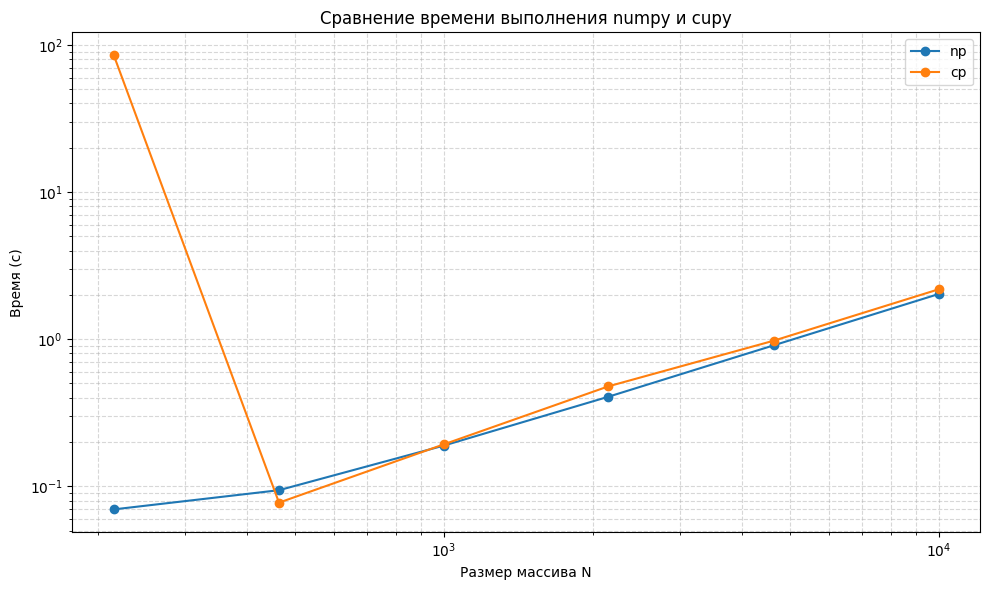

In [14]:
def compete4(M_mas, lib_mas, func_mas, step = 1, counts=3):
    mmas = []
    for i, M in enumerate(M_mas):
        mmas.append([])
        for j, lib in enumerate(lib_mas):
            sum_time = 0
            for k in range(counts):
                pretty_load(i*len(lib_mas) + j, len(M_mas) * len(lib_mas))
                arr1 = lib.arange(-10, 10+step, step)
                start = time.time()
                result = func_mas[j](arr1, M) 
                sum_time += time.time() - start
            mmas[-1].append(sum_time/counts)
    pretty_load(len(M_mas) * len(lib_mas), len(N_mas) * len(lib_mas))
    return mmas


def func4_np(x, M):
    x = np.asarray(x, dtype=float)
    result = np.zeros_like(x)
    if M <= 0:
        return result

    term = x.copy()
    result += term
    x2 = x * x

    for k in range(1, M):
        term *= -x2         
        term /= (2 * k) * (2 * k + 1)  
        result += term
    return result

def func4_cp(x, M):
    x = cp.asarray(x, dtype=float)
    result = cp.zeros_like(x)
    if M <= 0:
        return result

    term = x.copy()
    result += term
    x2 = x * x

    for k in range(1, M):
        term *= -x2         
        term /= (2 * k) * (2 * k + 1)  
        result += term
    return result


M_mas = [215, 464, 1000, 2150, 4640, 10000]
res = compete4(M_mas, [np, cp], [func4_np, func4_cp], step = 0.0001)

print(f"""\n{"N count":<12}\t{"np":<12}\t{"cp":<12}""")
for i, row in enumerate(res):
    print(f"{M_mas[i]:<12}\t{row[0]:<12.9f}\t{row[1]:<12.9f}")


plot_results(M_mas, res, labels=['np', 'cp'],
             title='Сравнение времени выполнения numpy и cupy',
             xlabel='Размер массива N', ylabel='Время (с)',
             log_scale=True)